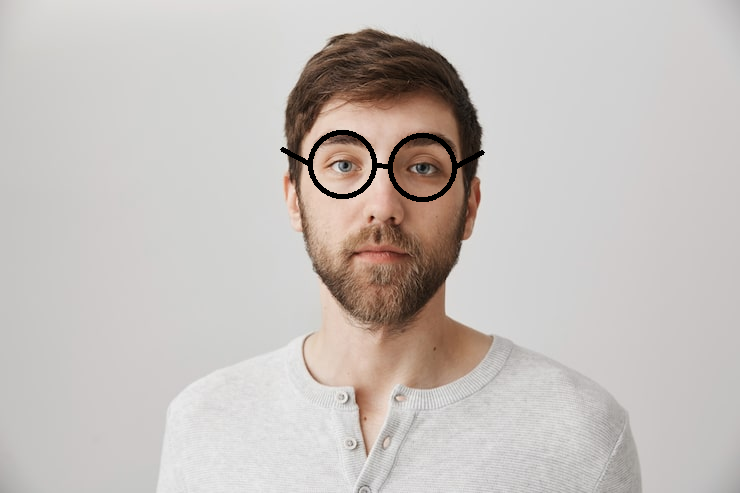

Обработан test_0


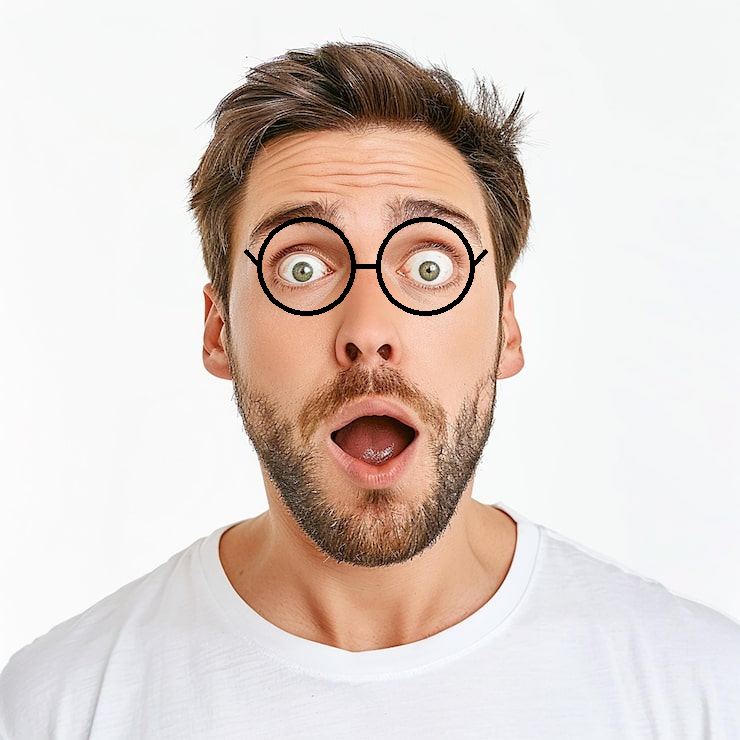

Обработан test_1


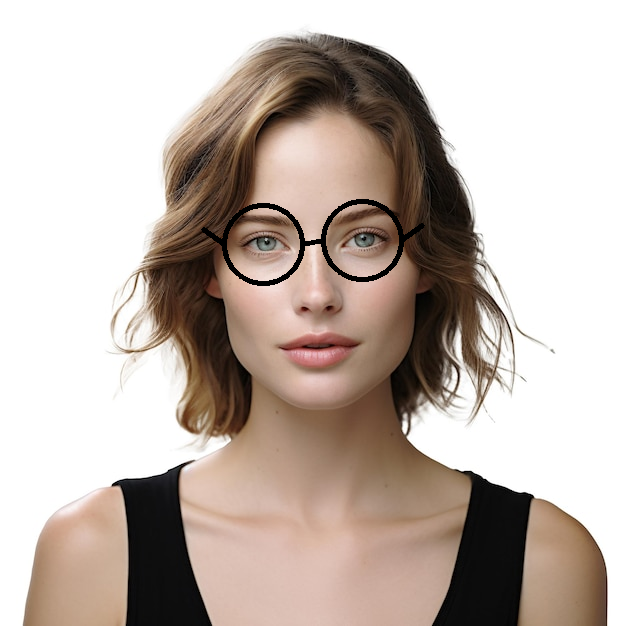

Обработан test_2


In [ ]:
import cv2, numpy as np, os
from IPython.display import Image, display
import PIL.Image

os.makedirs('meow', exist_ok=True)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

for i in range(10):
    img = cv2.imread(f'test_{i}.png') or cv2.imread(f'test_{i}.jpg')
    if img is None: continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    if len(faces) > 0:
        fx, fy, fw, fh = faces[0]
        roi_gray = gray[fy:fy+fh, fx:fx+fw]
        eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 3)

        # Фильтруем: глаза должны быть в верхней половине лица
        eyes = [e for e in eyes if e[1] < fh * 0.5]

        if len(eyes) >= 2:
            eyes = sorted(eyes, key=lambda e: e[0])[:2]
            (ex1, ey1, ew1, eh1), (ex2, ey2, ew2, eh2) = eyes
            lx, ly = fx + ex1 + ew1//2, fy + ey1 + eh1//2
            rx, ry = fx + ex2 + ew2//2, fy + ey2 + eh2//2
            r = int(np.sqrt((rx-lx)**2 + (ry-ly)**2) * 0.4)

            cv2.circle(img, (lx, ly), r, (0,0,0), 3)
            cv2.circle(img, (rx, ry), r, (0,0,0), 3)
            cv2.line(img, (lx+r, ly), (rx-r, ry), (0,0,0), 3)
            cv2.line(img, (lx-r, ly), (lx-60, ly-15), (0,0,0), 3)
            cv2.line(img, (rx+r, ry), (rx+60, ry-15), (0,0,0), 3)

    cv2.imwrite(f'meow/test_{i}_glasses.png', img)
    display(PIL.Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)))
    print(f'Обработан test_{i}')

26-04-18 21:01:18 - 🔗 deploy.prototxt will be downloaded from https://github.com/opencv/opencv/raw/3.4.0/samples/dnn/face_detector/deploy.prototxt to /root/.deepface/weights/deploy.prototxt...


Downloading...
From: https://github.com/opencv/opencv/raw/3.4.0/samples/dnn/face_detector/deploy.prototxt
To: /root/.deepface/weights/deploy.prototxt
28.1kB [00:00, 18.8MB/s]                   


26-04-18 21:01:18 - 🔗 res10_300x300_ssd_iter_140000.caffemodel will be downloaded from https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel to /root/.deepface/weights/res10_300x300_ssd_iter_140000.caffemodel...


Downloading...
From: https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel
To: /root/.deepface/weights/res10_300x300_ssd_iter_140000.caffemodel
100%|██████████| 10.7M/10.7M [00:00<00:00, 213MB/s]


Ошибка: 'landmarks'


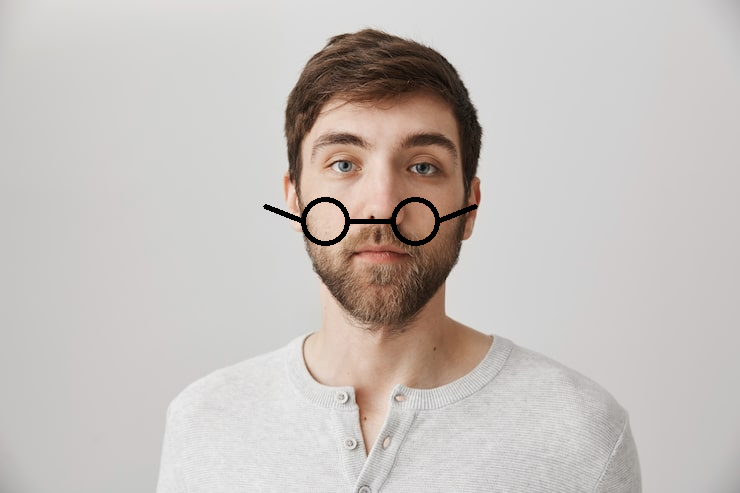

Обработан test_0
Ошибка: 'landmarks'


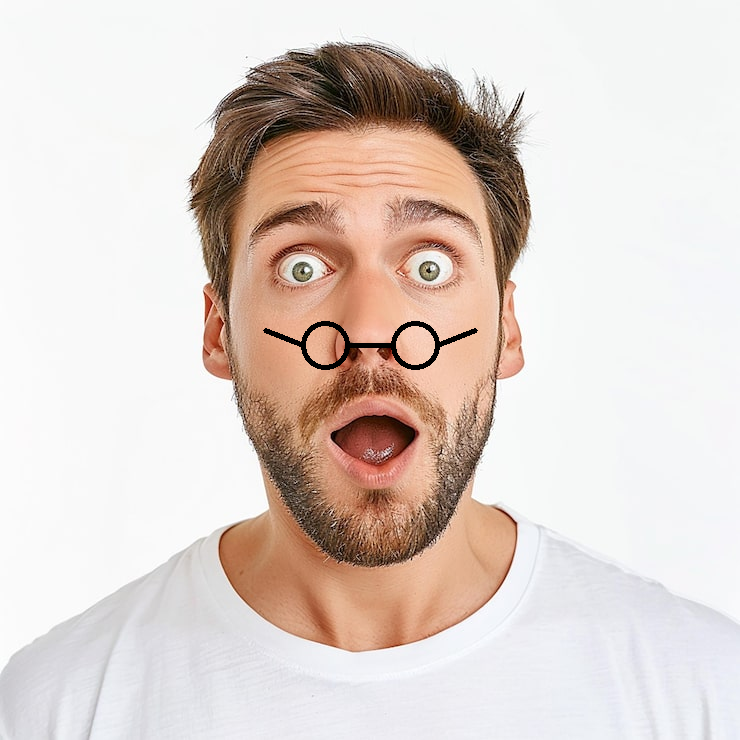

Обработан test_1
Ошибка: 'landmarks'


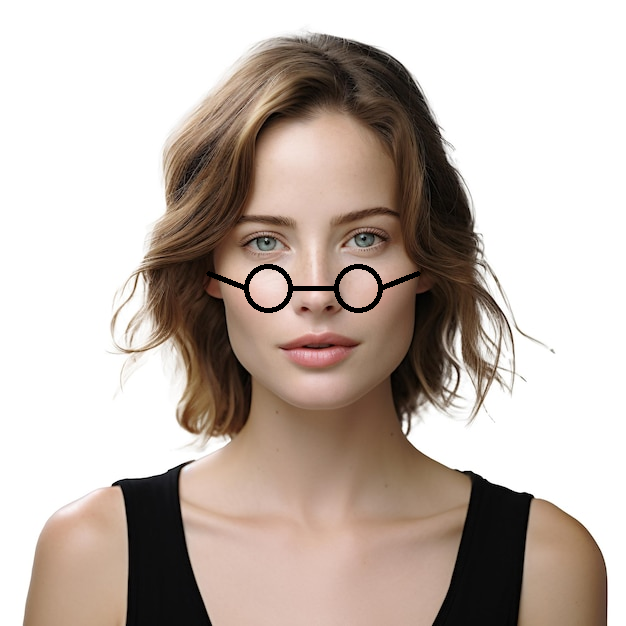

Обработан test_2


In [ ]:
import cv2, numpy as np, os
from deepface import DeepFace
from IPython.display import Image, display
import PIL.Image

os.makedirs('meow', exist_ok=True)

# detector_backend варианты:
# 'opencv' - Haar Cascade (быстрый, легкий)
# 'dlib' - HOG + SVM (точный, 68 точек лица)
# 'mtcnn' - MTCNN нейросеть (хорош для фронтальных фото)
# 'retinaface' - RetinaFace (мощный, но медленный)
# 'mediapipe' - Google MediaPipe (468 точек, очень точный)
# 'ssd' - Single Shot Detector (баланс скорости/точности)
# 'yolov8' - YOLOv8 (современный, требует ultralytics)
# 'centerface' - CenterFace (легкий, быстрый)

for i in range(10):
    img = cv2.imread(f'test_{i}.png') or cv2.imread(f'test_{i}.jpg')
    if img is None: continue

    try:
        face = DeepFace.extract_faces(img, detector_backend='ssd')[0]
        area = face['facial_area']
        x, y, w, h = area['x'], area['y'], area['w'], area['h']

        # dlib возвращает абсолютные координаты, не нужно преобразовывать
        lm = face['landmarks']
        lx, ly = int(lm['left_eye'][0]), int(lm['left_eye'][1])
        rx, ry = int(lm['right_eye'][0]), int(lm['right_eye'][1])

        dist = int(np.sqrt((rx-lx)**2 + (ry-ly)**2) * 0.45)

        cv2.circle(img, (lx, ly), dist, (0,0,0), 3)
        cv2.circle(img, (rx, ry), dist, (0,0,0), 3)
        cv2.line(img, (lx+dist, ly), (rx-dist, ry), (0,0,0), 3)
        cv2.line(img, (lx-dist, ly), (lx-60, ly-15), (0,0,0), 3)
        cv2.line(img, (rx+dist, ry), (rx+60, ry-15), (0,0,0), 3)

    except Exception as e:
        print(f'Ошибка: {e}')
        h, w = img.shape[:2]
        lx, ly, rx, ry = w//2-45, h//2-25, w//2+45, h//2-25
        dist = 22
        cv2.circle(img, (lx, ly), dist, (0,0,0), 3)
        cv2.circle(img, (rx, ry), dist, (0,0,0), 3)
        cv2.line(img, (lx+dist, ly), (rx-dist, ry), (0,0,0), 3)
        cv2.line(img, (lx-dist, ly), (lx-60, ly-15), (0,0,0), 3)
        cv2.line(img, (rx+dist, ry), (rx+60, ry-15), (0,0,0), 3)

    cv2.imwrite(f'meow/test_{i}_glasses.png', img)
    display(PIL.Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)))
    print(f'Обработан test_{i}')

In [ ]:
import cv2, numpy as np, os
from IPython.display import Image, display
import PIL.Image

os.makedirs('meow', exist_ok=True)

# Загрузка каскадов
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
left_eye = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_lefteye_2splits.xml')
right_eye = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_righteye_2splits.xml')

for i in range(10):
    img = cv2.imread(f'tests/test_{i}.png') or cv2.imread(f'tests/test_{i}.jpg')
    if img is None: continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # CLAHE для улучшения контраста
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)
    gray = cv2.GaussianBlur(gray, (3,3), 0)

    faces = face_cascade.detectMultiScale(gray, 1.05, 4, minSize=(100,100))
    if len(faces) == 0: continue

    fx, fy, fw, fh = faces[0]
    roi = gray[fy:fy+int(fh*0.6), fx:fx+fw]  # Только верхние 60%

    # Мульти-масштабный поиск
    eyes = []
    for scale in [1.01, 1.05, 1.1]:
        e = eye_cascade.detectMultiScale(roi, scale, 2, minSize=(20,20), maxSize=(80,80))
        if len(e) >= 2:
            eyes = e
            break

    # Если не нашли - пробуем отдельные каскады
    if len(eyes) < 2:
        l = left_eye.detectMultiScale(roi, 1.05, 3, minSize=(20,20))
        r = right_eye.detectMultiScale(roi, 1.05, 3, minSize=(20,20))
        eyes = list(l) + list(r)

    # Фильтрация: глаза в верхней части и на одном уровне
    eyes = [e for e in eyes if e[1] < fh*0.5]
    valid = []
    for j, e1 in enumerate(eyes):
        for e2 in eyes[j+1:]:
            if abs(e1[1] - e2[1]) < 20 and 40 < abs(e1[0] - e2[0]) < 120:
                valid = [e1, e2]
                break
        if valid: break

    if len(valid) >= 2:
        eyes = sorted(valid, key=lambda e: e[0])[:2]
        (ex1, ey1, ew1, eh1), (ex2, ey2, ew2, eh2) = eyes
        lx, ly = fx + ex1 + ew1//2, fy + ey1 + eh1//2
        rx, ry = fx + ex2 + ew2//2, fy + ey2 + eh2//2

        # Уточнение центров через HoughCircles
        for (x, y, ew, eh) in [(lx-ew1, ly-eh1, ew1*2, eh1*2), (rx-ew2, ry-eh2, ew2*2, eh2*2)]:
            eye_roi = gray[max(0,y):y+eh, max(0,x):x+ew]
            circles = cv2.HoughCircles(eye_roi, cv2.HOUGH_GRADIENT, 1, 10, param1=100, param2=15, minRadius=5, maxRadius=15)
            if circles is not None:
                cx, cy, _ = circles[0][0]
                if x == lx - ew1: lx, ly = x + int(cx), y + int(cy)
                else: rx, ry = x + int(cx), y + int(cy)

        # Рисуем очки
        dist = int(np.sqrt((rx-lx)**2 + (ry-ly)**2) * 0.4)
        overlay = img.copy()
        cv2.circle(overlay, (lx, ly), dist, (30,30,30), -1)
        cv2.circle(overlay, (rx, ry), dist, (30,30,30), -1)
        cv2.addWeighted(overlay, 0.15, img, 0.85, 0, img)
        cv2.circle(img, (lx, ly), dist, (0,0,0), 3)
        cv2.circle(img, (rx, ry), dist, (0,0,0), 3)
        cv2.line(img, (lx+dist, ly), (rx-dist, ry), (0,0,0), 3)
        cv2.line(img, (lx-dist, ly), (lx-60, ly-15), (0,0,0), 3)
        cv2.line(img, (rx+dist, ry), (rx+60, ry-15), (0,0,0), 3)

    cv2.imwrite(f'meow/test_{i}_glasses.png', img)
    display(PIL.Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)))
    print(f'Обработан test_{i}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.0 MB/s eta 0:00:00


In [38]:
from google.colab.patches import cv2_imshow

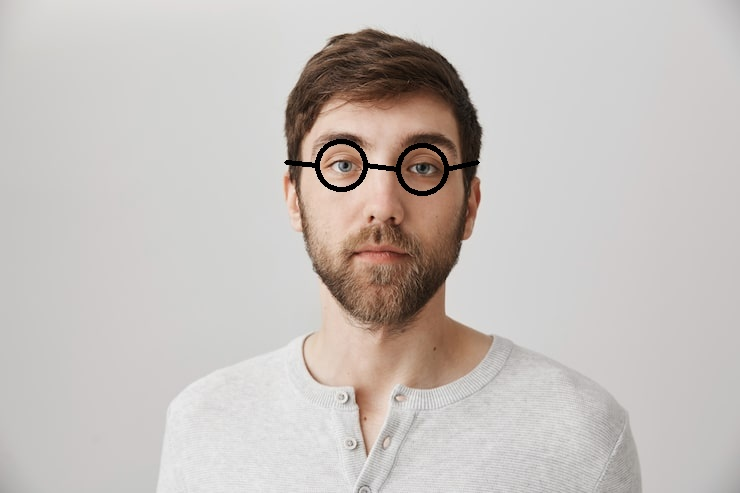

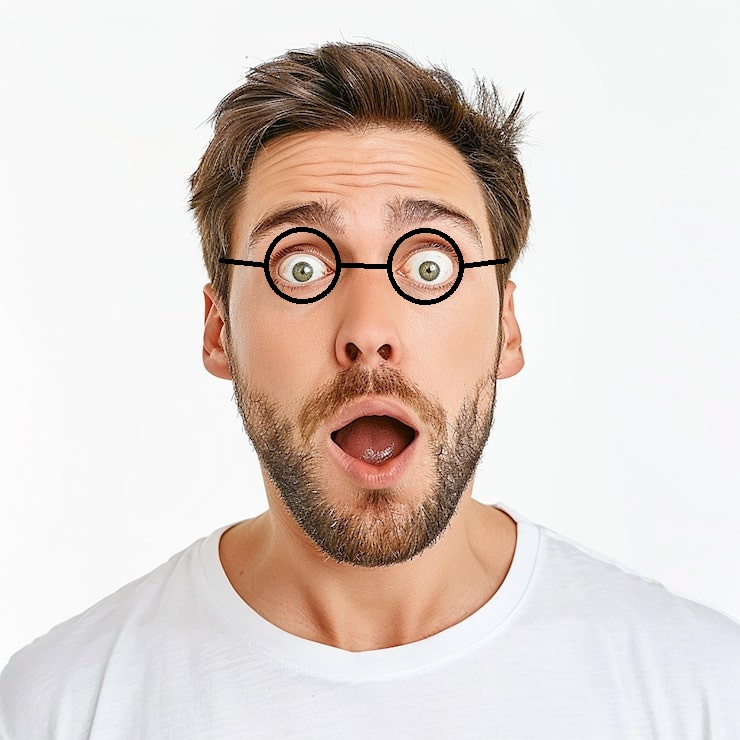

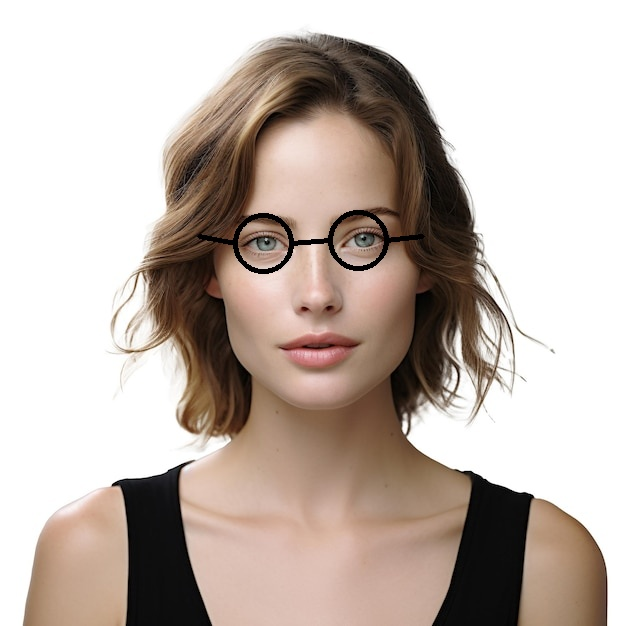

In [5]:
import cv2
import numpy as np
from pathlib import Path
from IPython.display import display, Image as IPImage

Path("meow").mkdir(exist_ok=True)

def detect_eyes(img):
    """Детекция глаз через Haar Cascades с CLAHE"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    if len(faces) == 0:
        return None, None

    fx, fy, fw, fh = faces[0]
    face_roi = gray[fy:fy+int(fh*0.6), fx:fx+fw]
    eyes = eye_cascade.detectMultiScale(face_roi, 1.1, 5, minSize=(20, 20))

    if len(eyes) < 2:
        return None, None

    eyes = sorted(eyes, key=lambda e: e[0])
    left = (fx + eyes[0][0] + eyes[0][2]//2, fy + eyes[0][1] + eyes[0][3]//2)
    right = (fx + eyes[-1][0] + eyes[-1][2]//2, fy + eyes[-1][1] + eyes[-1][3]//2)

    if abs(left[1] - right[1]) < fw * 0.2:
        return left, right
    return None, None

def draw_glasses(img, le, re):
    """Рисуем очки"""
    dist = int(np.sqrt((re[0]-le[0])**2 + (re[1]-le[1])**2))
    r = int(dist * 0.3)
    cy = (le[1] + re[1]) // 2
    t = int(r * 1.3)

    cv2.circle(img, le, r, (0,0,0), 3)
    cv2.circle(img, re, r, (0,0,0), 3)
    cv2.line(img, (le[0]+r, le[1]), (re[0]-r, re[1]), (0,0,0), 3)
    cv2.line(img, (le[0]-r, le[1]), (le[0]-r-t, cy-5), (0,0,0), 3)
    cv2.line(img, (re[0]+r, re[1]), (re[0]+r+t, cy-5), (0,0,0), 3)
    return img

for img_path in sorted(Path("tests").glob("test_*.*")):
    img = cv2.imread(str(img_path))
    le, re = detect_eyes(img)
    if le and re:
        img = draw_glasses(img, le, re)
    out = f"meow/{img_path.name}"
    cv2.imwrite(out, img)
    display(IPImage(filename=out))